# Read-only training review: `training072926`

This notebook reads the two stored runs, their logs, exported feature files, and evaluation CSVs. It does not load checkpoints, train models, or select models with test metrics.

## 1. Setup and required artifacts

In [1]:
from pathlib import Path
import json
import os
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 44)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.titlesize": 12, "axes.labelsize": 10})

default_training_root = Path("C:/Users/anton/Desktop/training072926")
if not default_training_root.is_dir():
    default_training_root = Path("/mnt/c/Users/anton/Desktop/training072926")
training_root = Path(os.environ.get("OMNIXAS_TRAINING_072926_ROOT", default_training_root)).expanduser().resolve()
if not training_root.is_dir():
    raise FileNotFoundError(
        f"Training export not found: {training_root}. Set OMNIXAS_TRAINING_072926_ROOT to its directory."
    )

dataset_order = [
    "Ti_FEFF", "V_FEFF", "Cr_FEFF", "Mn_FEFF",
    "Fe_FEFF", "Co_FEFF", "Ni_FEFF", "Cu_FEFF",
    "Ti_VASP", "Cu_VASP",
]
runs = [
    {
        "run": "e2e_expert_seed42",
        "scope": "8 FEFF Expert heads",
        "root": training_root / "m3gnetAll8E2EExperts" / "e2e_expert_seed42",
        "metrics_path": training_root / "m3gnetAll8E2EExperts" / "e2e_expert_seed42" / "e2e_logs" / "version_0" / "metrics.csv",
        "eval_path": training_root / "m3gnetAll8E2EExperts" / "e2e_expert_seed42" / "continued_expert_eval.csv",
        "expected_eval_datasets": dataset_order[:8],
        "expected_feature_datasets": dataset_order,
        "setting_keys": ["seed", "gnn_dropout", "head_dropout", "e2e_epochs", "encoder_lr", "head_lr", "continue_epochs", "continue_lr", "continue_patience"],
    },
    {
        "run": "vasp_encoder_seed42",
        "scope": "Ti/Cu VASP Expert heads",
        "root": training_root / "vaspOnlyEncoderExperts" / "vasp_encoder_seed42",
        "metrics_path": training_root / "vaspOnlyEncoderExperts" / "vasp_encoder_seed42" / "encoder_logs" / "version_0" / "metrics.csv",
        "eval_path": training_root / "vaspOnlyEncoderExperts" / "vasp_encoder_seed42" / "expert_eval.csv",
        "expected_eval_datasets": ["Ti_VASP", "Cu_VASP"],
        "expected_feature_datasets": ["Ti_VASP", "Cu_VASP"],
        "setting_keys": ["seed", "gnn_dropout", "encoder_epochs", "encoder_lr", "expert_epochs", "expert_lr", "expert_dropout", "expert_patience"],
    },
]

for run in runs:
    run["settings_path"] = run["root"] / "run_settings.json"
    run["features_root"] = run["root"] / "features"
    required = [run["root"], run["settings_path"], run["metrics_path"], run["eval_path"], run["features_root"]]
    missing = [str(path) for path in required if not path.exists()]
    expected_feature_names = [
        f"{dataset}_{split}_{kind}.txt"
        for dataset in run["expected_feature_datasets"]
        for split in ["train", "val", "test"]
        for kind in ["X", "y"]
    ]
    missing.extend(str(run["features_root"] / name) for name in expected_feature_names if not (run["features_root"] / name).is_file())
    best_candidates = sorted((run["root"] / "checkpoints").glob("best-*.ckpt"))
    if len(best_candidates) != 1:
        missing.append(f"exactly one checkpoints/best-*.ckpt under {run['root']} (found {len(best_candidates)})")
    if missing:
        raise FileNotFoundError(f"Missing required artifacts for {run['run']}: {missing}")
    run["best_checkpoint"] = best_candidates[0]
    run["settings"] = json.loads(run["settings_path"].read_text(encoding="utf-8"))["args"]
    run["metrics"] = pd.read_csv(run["metrics_path"], usecols=['epoch', 'val_balanced_rel_mse'])
    run["eval"] = pd.read_csv(run["eval_path"])
    run["best_head_checkpoints"] = sorted(run["root"].glob('heads/**/best*.ckpt'))
    if len(run["best_head_checkpoints"]) != len(run["eval"]):
        raise FileNotFoundError(
            f"Expected {len(run['eval'])} validation-best head checkpoints under {run['root']} "
            f"to match {run['eval_path']} rows; found {len(run['best_head_checkpoints'])}."
        )
    run["feature_files"] = sorted(run["features_root"].glob("*.txt"))
    feature_datasets = set()
    for path in run["feature_files"]:
        match = re.fullmatch(r"(.+)_(?:train|val|test)_[Xy]\.txt", path.name)
        if match is None:
            raise ValueError(f"Unexpected feature filename: {path.name}")
        feature_datasets.add(match.group(1))
    if feature_datasets != set(run["expected_feature_datasets"]):
        raise ValueError(f"Unexpected exported datasets for {run['run']}: {sorted(feature_datasets)}")
    if set(run["eval"]["dataset"]) != set(run["expected_eval_datasets"]):
        raise ValueError(f"Unexpected evaluation datasets for {run['run']}")
    if run["eval"]["dataset"].duplicated().any():
        raise ValueError(f"Duplicate evaluation dataset for {run['run']}")
    run["metrics"]["epoch"] = pd.to_numeric(run["metrics"]["epoch"], errors="coerce")
    run["metrics"]["val_balanced_rel_mse"] = pd.to_numeric(run["metrics"]["val_balanced_rel_mse"], errors="coerce")
    run["val_curve"] = (
        run["metrics"].dropna(subset=["epoch", "val_balanced_rel_mse"])
        .groupby("epoch", as_index=False)["val_balanced_rel_mse"].min()
        .sort_values("epoch")
    )
    if run["val_curve"].empty:
        raise ValueError(f"No epoch-level validation rows in {run['metrics_path']}")
    run["best_row"] = run["val_curve"].loc[run["val_curve"]["val_balanced_rel_mse"].idxmin()]
    run["last_row"] = run["val_curve"].iloc[-1]

print(f"Training root: {training_root}")
print("Required artifact checks passed; no checkpoint was opened.")

Training root: /mnt/c/Users/anton/Desktop/training072926
Required artifact checks passed; no checkpoint was opened.


## 2. Run summary

In [2]:
summary_rows = []
for run in runs:
    settings = "; ".join(f"{key}={run['settings'].get(key)}" for key in run["setting_keys"])
    summary_rows.append({
        "run": run["run"],
        "scope": run["scope"],
        "completed epochs": int(run["val_curve"]["epoch"].nunique()),
        "best val_balanced_rel_mse": run["best_row"]["val_balanced_rel_mse"],
        "last val_balanced_rel_mse": run["last_row"]["val_balanced_rel_mse"],
        "best checkpoint": run["best_checkpoint"].name,
        "exported datasets": len(run["expected_feature_datasets"]),
        "feature files": len(run["feature_files"]),
        "evaluated heads": len(run["best_head_checkpoints"]),
        "key recorded settings": settings,
    })
summary = pd.DataFrame(summary_rows)
display(summary.style.format({
    "best val_balanced_rel_mse": "{:.5f}",
    "last val_balanced_rel_mse": "{:.5f}",
}))

,run,scope,completed epochs,best val_balanced_rel_mse,last val_balanced_rel_mse,best checkpoint,exported datasets,feature files,evaluated heads,key recorded settings
0,e2e_expert_seed42,8 FEFF Expert heads,300,0.08899,0.09266,best-epoch=281-val_balanced_rel_mse=0.08899.ckpt,10,60,8,seed=42; gnn_dropout=0.1; head_dropout=0.5; e2e_epochs=300; encoder_lr=0.001; head_lr=0.001; continue_epochs=600; continue_lr=0.0003; continue_patience=40
1,vasp_encoder_seed42,Ti/Cu VASP Expert heads,133,0.16140,0.16295,best-epoch=102-val_balanced_rel_mse=0.16140.ckpt,2,12,2,seed=42; gnn_dropout=0.1; encoder_epochs=300; encoder_lr=0.001; expert_epochs=1000; expert_lr=0.001; expert_dropout=0.5; expert_patience=25


## 3. Validation curves

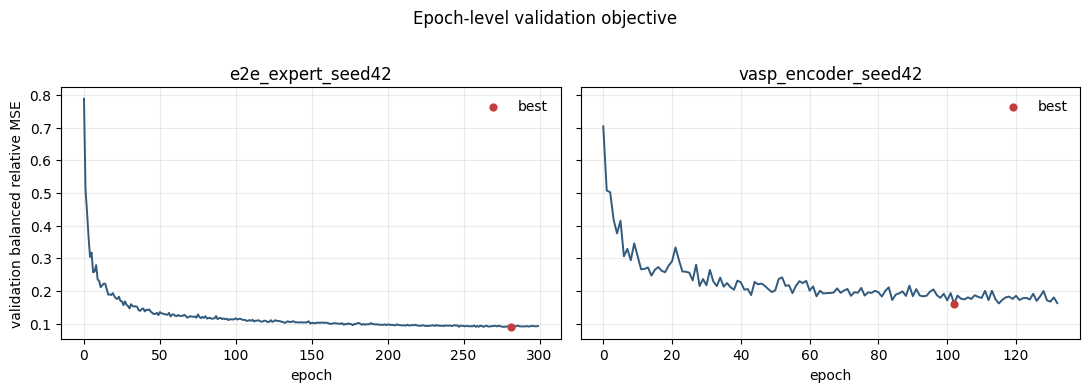

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, run in zip(axes, runs):
    curve = run["val_curve"]
    ax.plot(curve["epoch"], curve["val_balanced_rel_mse"], color="#315A7D", linewidth=1.4)
    ax.scatter([run["best_row"]["epoch"]], [run["best_row"]["val_balanced_rel_mse"]], color="#C43D3D", s=24, zorder=3, label="best")
    ax.set_title(run["run"])
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
axes[0].set_ylabel("validation balanced relative MSE")
fig.suptitle("Epoch-level validation objective", y=1.02)
fig.tight_layout()
plt.show()

## 4. Expert result comparison

In [4]:
paper_expert_test_eta = {
    "Ti_FEFF": 6.35, "V_FEFF": 7.30, "Cr_FEFF": 8.54, "Mn_FEFF": 17.66,
    "Fe_FEFF": 7.51, "Co_FEFF": 14.47, "Ni_FEFF": 8.45, "Cu_FEFF": 5.19,
    "Ti_VASP": 4.75, "Cu_VASP": 8.46,
}
result_frames = []
for run in runs:
    frame = run["eval"][["dataset", "val_eta", "test_eta"]].copy()
    frame["run"] = run["run"]
    frame["scope"] = run["scope"]
    result_frames.append(frame)

results = pd.concat(result_frames, ignore_index=True)
results["paper ExpertXAS test eta"] = results["dataset"].map(paper_expert_test_eta)
results["test delta vs paper"] = results["test_eta"] - results["paper ExpertXAS test eta"]
results = results.set_index("dataset").reindex(dataset_order).reset_index()
if results[["val_eta", "test_eta", "paper ExpertXAS test eta"]].isna().any().any():
    raise ValueError("The merged result table has a missing dataset or metric")

result_columns = ["dataset", "run", "scope", "val_eta", "test_eta", "paper ExpertXAS test eta", "test delta vs paper"]
display(results[result_columns].style.format({column: "{:.3f}" for column in result_columns[3:]}))

,dataset,run,scope,val_eta,test_eta,paper ExpertXAS test eta,test delta vs paper
0,Ti_FEFF,e2e_expert_seed42,8 FEFF Expert heads,10.062,9.624,6.350,3.274
1,V_FEFF,e2e_expert_seed42,8 FEFF Expert heads,11.681,9.661,7.300,2.361
2,Cr_FEFF,e2e_expert_seed42,8 FEFF Expert heads,13.265,12.794,8.540,4.254
3,Mn_FEFF,e2e_expert_seed42,8 FEFF Expert heads,25.001,23.870,17.660,6.210
4,Fe_FEFF,e2e_expert_seed42,8 FEFF Expert heads,12.601,12.295,7.510,4.785
5,Co_FEFF,e2e_expert_seed42,8 FEFF Expert heads,24.030,21.859,14.470,7.389
6,Ni_FEFF,e2e_expert_seed42,8 FEFF Expert heads,15.732,15.819,8.450,7.369
7,Cu_FEFF,e2e_expert_seed42,8 FEFF Expert heads,6.819,6.526,5.190,1.336
8,Ti_VASP,vasp_encoder_seed42,Ti/Cu VASP Expert heads,5.245,5.761,4.750,1.011
9,Cu_VASP,vasp_encoder_seed42,Ti/Cu VASP Expert heads,9.015,8.758,8.460,0.298


Selection is validation-based (`val_balanced_rel_mse` for the encoders and stored validation-selected head checkpoints); test eta is reported only for comparison.